# Aggregation of Calculated Brain Measures

This notebook represents the final refinement stage of the neuroimaging pipeline. It serves as the bridge between the cluster computation and the structural equation modeling (SEM) by aggregating the parallelized outputs into a unified, robust dataset.

Using the **real calculated brain measures from the 54 batch-wise CSVs** as input, this workflow performs quality control and feature integration. Specifically, it evaluates the stability of graph-theoretical metrics across multiple network density thresholds to determine the optimal range for Area Under the Curve (AUC) integration. The final output is a consolidated, subject-level dataframe containing the nine  scalar brain metrics required for the subsequent SEM. To maintain compliance with the HCP Restricted Data Use Agreement while allowing for public inspection of the results, the **final CSV contains real analytical data, but the "Subject" column has been anonymized with randomized identifiers**. Consequently, while the dataset is transparent for review, researchers wishing to reproduce the exact SEM linkage **must omit the ID-replacement code block** in the Export section to maintain the original subject keys.


### Notebook Structure:
- **Batch Aggregation**: Identification, sorting, and vertical stacking of the 54 batch-specific CSV files
- **Density Evaluation**: Generation of correlation matrices for each network density threshold to assess metric stability and collinearity
- **Threshold Selection**: Selection of the specific density range (4 out of 5 densities) for integration
- **AUC Integration**: Calculation of the Area Under the Curve (AUC) for density-dependent metrics to create robust, threshold-independent measures
- **Final Validation**: Visualization of the participant-averaged graph measures across density thresholds and the final AUC-integrated correlation matrix
- **Export**: Saving the global scalar metrics in the finalized `brain_measures_for_SEM.csv` with anonymized identifiers
---

In [ ]:
# Set-Up
import os
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


# Paths
# IMPORTANT: Update path below for your environment.
# INPUT_DIR: Directory containing your fc_measures.py results (54 CSVs).
INPUT_DIR = r"YOUR\PATH\TO\FOLDER\CONTAINING\CSVS" 
FILE_PREFIX = "brain_measures_" 
OUTPUT_FILE = "brain_measures_for_SEM.csv"

### Batch Aggregation

In [2]:
# Find all files
all_items = os.listdir(INPUT_DIR)

csv_files = [
    os.path.join(INPUT_DIR, f) 
    for f in all_items 
    if f.startswith(FILE_PREFIX) and f.endswith(".csv")
]

# Sort the files 
csv_files = sorted(csv_files, key=lambda x: int(re.search(r'(\d+)', os.path.basename(x)).group()))
print(f"Found {len(csv_files)} CSV files.")

# Read and Stack CSVs
try:
    full_df = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)
except ValueError as e:
    print(f"Error during stacking: {e}")
        
print(f"Successfully stacked data.")
print(f"Total subjects: {full_df.shape[0]}")
print(f"Total measures: {full_df.shape[1]-1}") # minus 1 Subject ID col

# Drop participants with missing data (N=11 dropped)
# Note: Missingness was due to random HPC I/O conflicts during atlas download, 
# not systematic subject-level factors.
full_df.dropna(inplace=True)

print(f"Successfully removed NaN containing rows.")
print(f"Total subjects: {full_df.shape[0]}")
print(f"Total measures: {full_df.shape[1]-1}") # minus 1 Subject ID col

Found 54 CSV files.
Successfully stacked data.
Total subjects: 1071
Total measures: 37
Successfully removed NaN containing rows.
Total subjects: 1060
Total measures: 37


### Density Evaluation

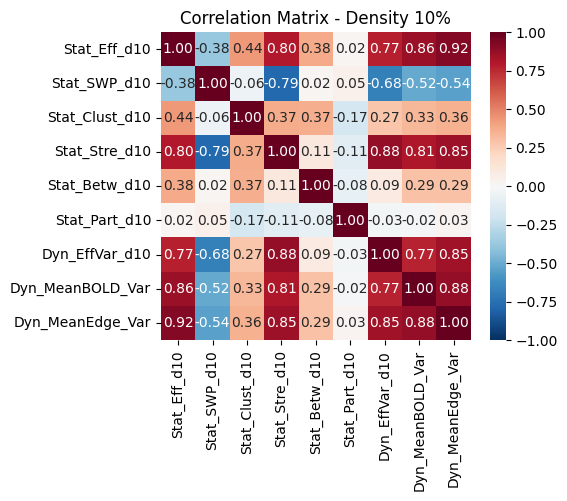

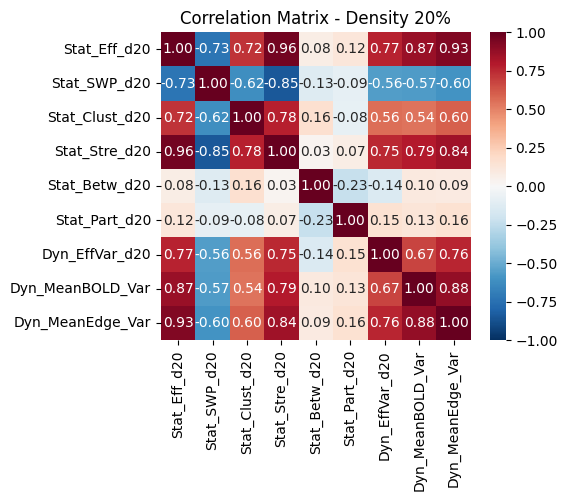

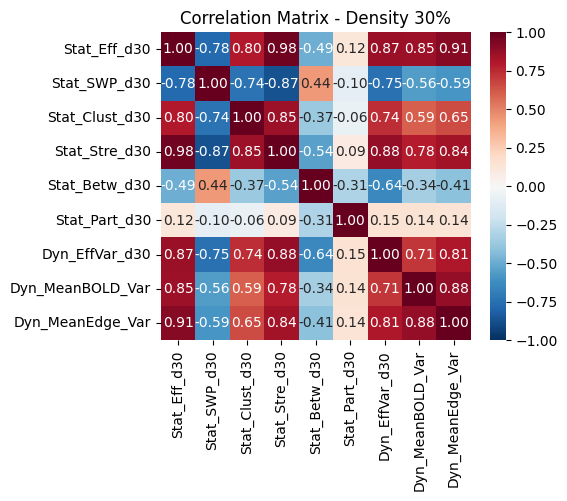

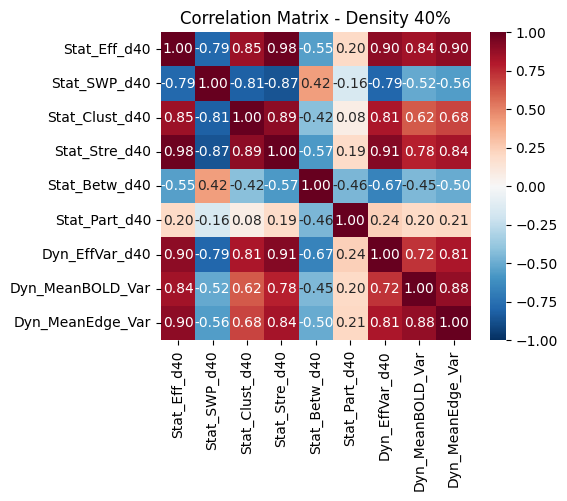

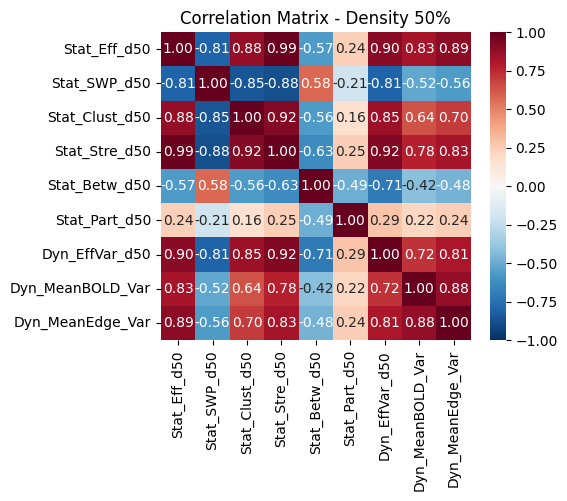

In [3]:
# Correlation heatmaps of calculated brain measures for single densities 0.1 to 0.5

densities = ['10', '20', '30', '40', '50']
measures = ['Stat_Eff', 'Stat_SWP', 'Stat_Clust', 'Stat_Stre',  'Stat_Betw', 'Stat_Part', 'Dyn_EffVar']
static_cols = ['Dyn_MeanBOLD_Var', 'Dyn_MeanEdge_Var']

for d in densities:
    current_density_cols = [f"{m}_d{d}" for m in measures]
    all_cols = current_density_cols + static_cols
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        full_df[all_cols].corr(), 
        annot=True, 
        fmt=".2f", 
        vmin=-1, 
        vmax=1, 
        cmap='RdBu_r'
    )
    plt.title(f"Correlation Matrix - Density {d}%")
    plt.show()

### Threshold Selection

Following a visual inspection of the density-specific correlation heatmaps, we restricted the Area Under the Curve (AUC) integration to the 0.2-0.5 density range. The lowest threshold (0.1) was excluded due to visible instability, manifesting as a correlation pattern that diverged significantly from the consistent trends observed at higher densities. While these unique fluctuations at the 0.1 level may hold potentially meaningful signal, we opted to prioritize the internal consistency of the aggregate measures. By excluding this outlier threshold, we ensured that the final brain features represent the more stable, converging network patterns. 

### AUC Integration
Calculate AUCs for density-dependent measures excluding density 0.1

In [4]:
# Measures mapping
measures_map = {
    'Stat_Eff':   'Stat_Eff_AUC',
    'Stat_SWP':   'Stat_SWP_AUC',
    'Stat_Clust': 'Stat_Clust_AUC',
    'Stat_Stre':  'Stat_Stre_AUC',
    'Stat_Betw':  'Stat_Betw_AUC',
    'Stat_Part':  'Stat_Part_AUC',
    'Dyn_EffVar': 'Dyn_EffVar_AUC'
}

# x-axis for the AUC
densities = [0.2, 0.3, 0.4, 0.5]

# Loop through density-dependent measures and calculate AUC using np.trapezoid
for prefix, new_col_name in measures_map.items():  
    
    # Generate column names: 'Stat_Eff_d10', 'Stat_Eff_d20', etc.
    cols_to_integrate = [f"{prefix}_d{int(d*100):02d}" for d in densities] 
    if set(cols_to_integrate).issubset(full_df.columns):
        print(f"Calculating AUC for {prefix}.")
        # Calculate the AUC scalar 
        full_df[new_col_name] = np.trapezoid(full_df[cols_to_integrate], x=densities, axis=1)    
    else:
        print(f"Warning: Missing columns for {prefix}")


print(f" \nSuccessfully calculated AUCs.")
print(f"Total subjects: {full_df.shape[0]}")
print(f"Total measures: {full_df.shape[1]-1}") # minus 1 Subject ID col

Calculating AUC for Stat_Eff.
Calculating AUC for Stat_SWP.
Calculating AUC for Stat_Clust.
Calculating AUC for Stat_Stre.
Calculating AUC for Stat_Betw.
Calculating AUC for Stat_Part.
Calculating AUC for Dyn_EffVar.
 
Successfully calculated AUCs.
Total subjects: 1060
Total measures: 44


### Final Validation

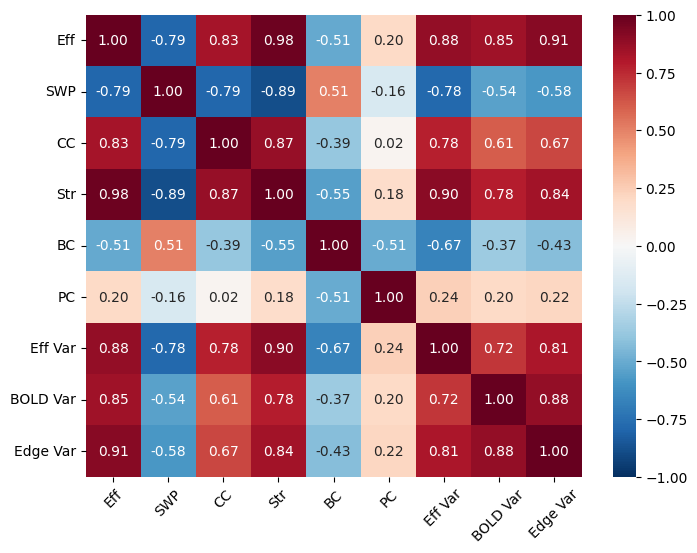

In [5]:
# Corr plot including AUC-integrated measures
# this plot is shown as Figure 4 on the poster

brain_cols = list(measures_map.values()) # the 7 calculated AUC measures
brain_cols += ['Dyn_MeanBOLD_Var', 'Dyn_MeanEdge_Var']
brain_desc_df = full_df[brain_cols].copy()

clean_labels = [
    'Eff', 
    'SWP', 
    'CC', 
    'Str', 
    'BC', 
    'PC', 
    'Eff Var', 
    'BOLD Var', 
    'Edge Var'
]

plt.figure(figsize=(8, 6))
sns.heatmap(brain_desc_df.corr(), annot=True, fmt=".2f", vmin=-1, vmax=1, cmap='RdBu_r',xticklabels=clean_labels, yticklabels=clean_labels)
plt.xticks(rotation=45)


plt.savefig('brain_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

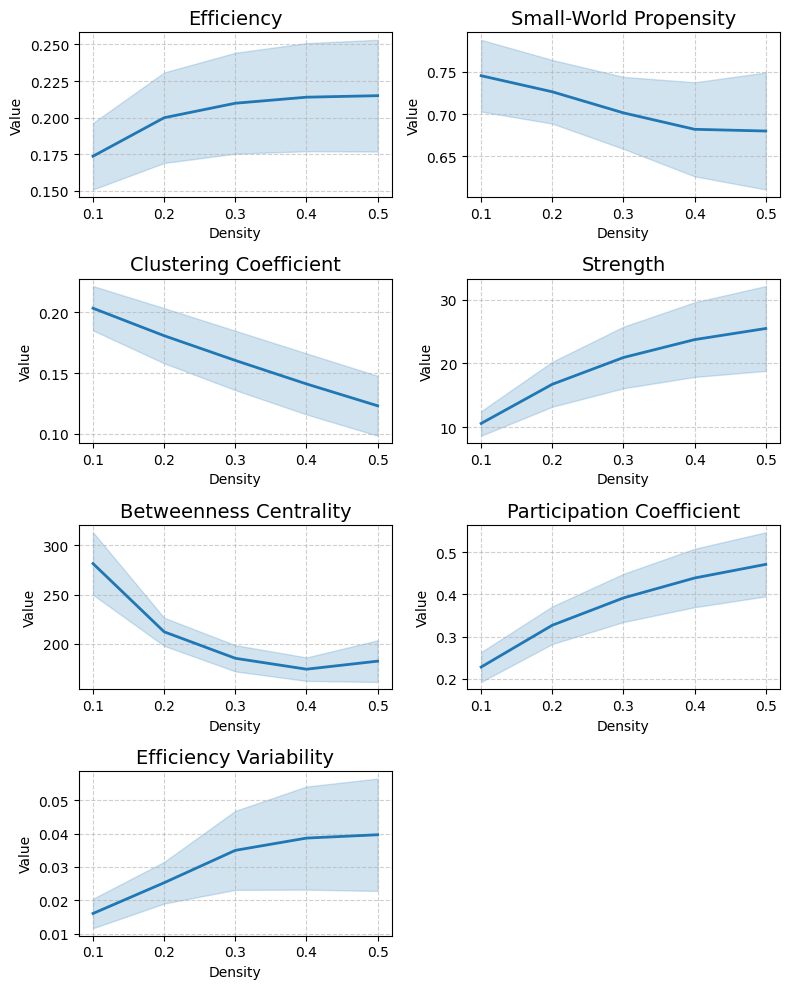

In [6]:
# Participant-averaged graph measures plotted against the network density thresholds
# this plot is shown as Figure 3 on the poster

# metrics to plot
metrics = {
    'Stat_Eff': 'Efficiency',
    'Stat_SWP': 'Small-World Propensity',
    'Stat_Clust': 'Clustering Coefficient',
    'Stat_Stre': 'Strength',
    'Stat_Betw': 'Betweenness Centrality',
    'Stat_Part': 'Participation Coefficient',
    'Dyn_EffVar': 'Efficiency Variability'
}

densities = [10, 20, 30, 40, 50]
density_labels = [0.1, 0.2, 0.3, 0.4, 0.5]

# plot set-up
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(8, 10), sharex=False)
axes = axes.flatten()

# loop trough metrics to create subplots
for i, (metric_prefix, display_name) in enumerate(metrics.items()):
    ax = axes[i]
    
    cols = [f"{metric_prefix}_d{d}" for d in densities]
    
    # data long format
    df_long = full_df.melt(value_vars=cols, var_name='Density_Raw', value_name='Value')
    
    density_map = {f"{metric_prefix}_d{d}": dl for d, dl in zip(densities, density_labels)}
    df_long['Density'] = df_long['Density_Raw'].map(density_map)
    
    # lineplot with sd
    sns.lineplot(data=df_long, x='Density', y='Value', ax=ax, errorbar='sd', linewidth=2)
    
    ax.set_title(display_name, fontsize=14)
    ax.set_xlabel('Density')
    ax.set_ylabel('Value')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_xticks(density_labels)

# remove last empty subplot
if len(metrics) < len(axes):
    for j in range(len(metrics), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('graph_measures_vs_density.png', dpi=300, bbox_inches='tight')
plt.show()

### Export

In [7]:
# Select only global scalar brain measures for SEM df

# cols to keep
final_cols = ['Subject'] # the Subject ID
final_cols += list(measures_map.values()) # the 7 calculated AUC measures
final_cols += ['Dyn_MeanBOLD_Var', 'Dyn_MeanEdge_Var'] # the 2 non-density dependent measures

# Create clean df for use in the SEM
brain_measure_df = full_df[final_cols].copy()
print(f"Total subjects: {brain_measure_df.shape[0]}")
print(f"Total measures: {brain_measure_df.shape[1]-1}") # minus 1 Subject ID col

# z-score measures
cols_to_z = brain_measure_df.columns.drop("Subject")

scaler = StandardScaler()
brain_measure_df_z = brain_measure_df.copy()
brain_measure_df_z[cols_to_z] = scaler.fit_transform(
    brain_measure_df[cols_to_z]
)

# Anonymize "Subject" column with randomized identifiers
# ==========================================
# DELETE OR COMMENT OUT THE LINE BELOW 
# IF REPRODUCING WITH YOUR OWN DATA
# ==========================================
brain_measure_df_z['Subject'] = [f"Subj_{i:02d}" for i in range(1, len(brain_measure_df_z) + 1)]

# Save final (z-scored) df
brain_measure_df_z.to_csv(OUTPUT_FILE, index=False)

print("Processing Complete.")
print(f"Shape containing measures dependent on densities: {full_df.shape}")
print(f"Shape containing only scalar brain measures (z-scored): {brain_measure_df_z.shape}")
print(f"\nFinal Columns:\n{brain_measure_df_z.columns.tolist()}")
print(f"\nSaved to: {OUTPUT_FILE}")

Total subjects: 1060
Total measures: 9
Processing Complete.
Shape containing measures dependent on densities: (1060, 45)
Shape containing only scalar brain measures (z-scored): (1060, 10)

Final Columns:
['Subject', 'Stat_Eff_AUC', 'Stat_SWP_AUC', 'Stat_Clust_AUC', 'Stat_Stre_AUC', 'Stat_Betw_AUC', 'Stat_Part_AUC', 'Dyn_EffVar_AUC', 'Dyn_MeanBOLD_Var', 'Dyn_MeanEdge_Var']

Saved to: brain_measures_for_SEM.csv
